# Analyse Exploratoire des Données (EDA) - Agriculture au Burkina Faso

Ce notebook présente une analyse exploratoire des données (EDA) pour les indicateurs agricoles et de développement rural au Burkina Faso. L'objectif est de comprendre les tendances, les corrélations et les défis majeurs pour le secteur agricole du pays.

**Source des données :** Banque Mondiale via Humanitarian Data Exchange (HDX)
**Lien direct :** [Dataset HDX - World Bank Indicators for Burkina Faso](https://data.humdata.org/dataset/cd97d950-0124-468b-9bf0-71d232e47668/resource/81856343-2ffc-4336-8eb6-c1bd90ec9759/download/agriculture-and-rural-development_bfa.csv)

## 1. Préparation de l'environnement et chargement des données

In [ ]:
!pip install pandas matplotlib seaborn tabulate

     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
      --------------------------------------- 0.1/8.2 MB 2.8 MB/s eta 0:00:03
     --- ------------------------------------ 0.8/8.2 MB 8.0 MB/s eta 0:00:01
     ----------- ---------------------------- 2.3/8.2 MB 18.2 MB/s eta 0:00:01
     ----------- ---------------------------- 2.4/8.2 MB 14.1 MB/s eta 0:00:01
     --------------- ------------------------ 3.2/8.2 MB 15.5 MB/s eta 0:00:01
     ---------------- ----------------------- 3.3/8.2 MB 14.1 MB/s eta 0:00:01
     ---------------------- ----------------- 4.6/8.2 MB 15.6 MB/s eta 0:00:01
     ----------------------- ---------------- 4.7/8.2 MB 13.7 MB/s eta 0:00:01
     ---------------------------- ----------- 5.8/8.2 MB 14.2 MB/s eta 0:00:01
     -------------------------------- ------- 6.7/8.2 MB 14.9 MB/s eta 0:00:01
     --------------------------------- ------ 6.9/8.2 MB 14.1 MB/s eta 0:00:01
     ------------------------------------- -- 7.8/8.2 MB 14.2 


[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: C:\Users\kkone\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Créer un dossier pour les graphiques
os.makedirs('plots', exist_ok=True)

# Télécharger le dataset si non présent (pour une exécution autonome du notebook)
# Note: Dans un environnement sandbox, le fichier est déjà téléchargé.
# Pour une exécution locale, vous pourriez décommenter et adapter cette partie.
# import requests
# url = "https://data.humdata.org/dataset/cd97d950-0124-468b-9bf0-71d232e47668/resource/81856343-2ffc-4336-8eb6-c1bd90ec9759/download/agriculture-and-rural-development_bfa.csv"
# if not os.path.exists('agriculture_burkina.csv'):
#     r = requests.get(url, allow_redirects=True)
#     open('agriculture_burkina.csv', 'wb').write(r.content)

# Charger les données
df = pd.read_csv('agriculture_burkina.csv', header=None, names=['Country', 'ISO3', 'Year', 'Indicator', 'Code', 'Value'])

print("Aperçu des 5 premières lignes du dataset :")
print(df.head())
print("Informations sur le dataset :")
print(df.info())


Aperçu des 5 premières lignes du dataset :
        Country          ISO3  Year  \
0  Country Name  Country ISO3  Year   
1  Burkina Faso           BFA  2000   
2  Burkina Faso           BFA  1999   
3  Burkina Faso           BFA  1998   
4  Burkina Faso           BFA  1997   

                                           Indicator               Code  \
0                                     Indicator Name     Indicator Code   
1  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   
2  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   
3  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   
4  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   

              Value  
0             Value  
1  8857.18015665796  
2  4822.22222222222  
3             16744  
4  14192.3333333333  
Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1724 entries, 0 to 1723
Data columns (total 6 columns):
 # 

## 2. Nettoyage et Pré-traitement des Données

Nous allons nettoyer les données en convertissant les colonnes 'Year' et 'Value' en types numériques et en supprimant les lignes avec des valeurs manquantes.

In [9]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
df = df.dropna(subset=['Year', 'Value'])

print("Aperçu des 5 premières lignes après nettoyage :")
print(df.head())
print("Informations sur le dataset après nettoyage :")
print(df.info())


Aperçu des 5 premières lignes après nettoyage :
        Country ISO3    Year  \
1  Burkina Faso  BFA  2000.0   
2  Burkina Faso  BFA  1999.0   
3  Burkina Faso  BFA  1998.0   
4  Burkina Faso  BFA  1997.0   
5  Burkina Faso  BFA  1996.0   

                                           Indicator               Code  \
1  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   
2  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   
3  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   
4  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   
5  Fertilizer consumption (% of fertilizer produc...  AG.CON.FERT.PT.ZS   

          Value  
1   8857.180157  
2   4822.222222  
3  16744.000000  
4  14192.333333  
5   8031.666667  
Informations sur le dataset après nettoyage :
<class 'pandas.core.frame.DataFrame'>
Index: 1723 entries, 1 to 1723
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------  

## 3. Statistiques Descriptives

Nous allons calculer les statistiques descriptives pour les indicateurs clés afin d'avoir un aperçu de leur distribution et de leurs valeurs centrales.

In [11]:
indicators = [
    'Cereal yield (kg per hectare)',
    'Agricultural land (% of land area)',
    'Arable land (% of land area)',
    'Rural population (% of total population)',
    'Access to electricity, rural (% of rural population)',
    'Fertilizer consumption (% of fertilizer production)' # Ajouté pour l'analyse
]

summary_stats = df[df['Indicator'].isin(indicators)].groupby('Indicator')['Value'].describe()
print("Statistiques descriptives pour les indicateurs clés :")
print(summary_stats.to_markdown())


Statistiques descriptives pour les indicateurs clés :
| Indicator                                            |   count |        mean |         std |       min |       25% |        50% |         75% |        max |
|:-----------------------------------------------------|--------:|------------:|------------:|----------:|----------:|-----------:|------------:|-----------:|
| Access to electricity, rural (% of rural population) |      23 |     1.95016 |    0.805973 |    1      |    1.45   |    1.89743 |     2.14516 |     4.7    |
| Agricultural land (% of land area)                   |      63 |    39.432   |    6.88342  |   32.9496 |   33.0227 |   37.2897  |    44.6604  |    53.402  |
| Arable land (% of land area)                         |      63 |    16.9437  |    6.24012  |   10.9649 |   10.9649 |   15.1041  |    22.2326  |    28.9013 |
| Cereal yield (kg per hectare)                        |      64 |   802.984   |  271.253    |  408.5    |  550.775  |  819.5     |  1016.73    |  1261

## 4. Visualisations

Chaque graphique est produit dans une cellule dédiée. Les figures sont enregistrées sous `plots/` (fichiers PNG séparés).


In [13]:
sns.set_style("whitegrid")

data_yield = df[df['Indicator'] == 'Cereal yield (kg per hectare)'].sort_values('Year')
data_land = df[df['Indicator'] == 'Agricultural land (% of land area)'].sort_values('Year')
data_pop = df[df['Indicator'] == 'Rural population (% of total population)'].sort_values('Year')
data_elec = df[df['Indicator'] == 'Access to electricity, rural (% of rural population)'].sort_values('Year')

pivot_df = df[df['Indicator'].isin(indicators)].pivot_table(index='Year', columns='Indicator', values='Value')
corr_matrix = pivot_df.corr()


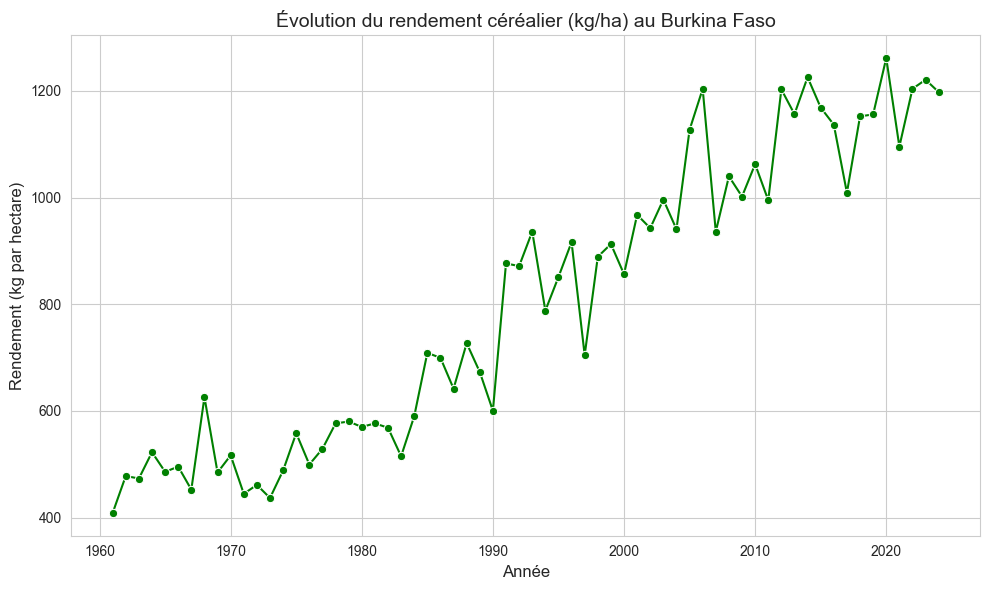

In [14]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=data_yield, x='Year', y='Value', marker='o', color='green')
plt.title('Évolution du rendement céréalier (kg/ha) au Burkina Faso', fontsize=14)
plt.ylabel('Rendement (kg par hectare)', fontsize=12)
plt.xlabel('Année', fontsize=12)
plt.tight_layout()
plt.savefig('plots/rendement_cerealier.png', dpi=150)
plt.show()


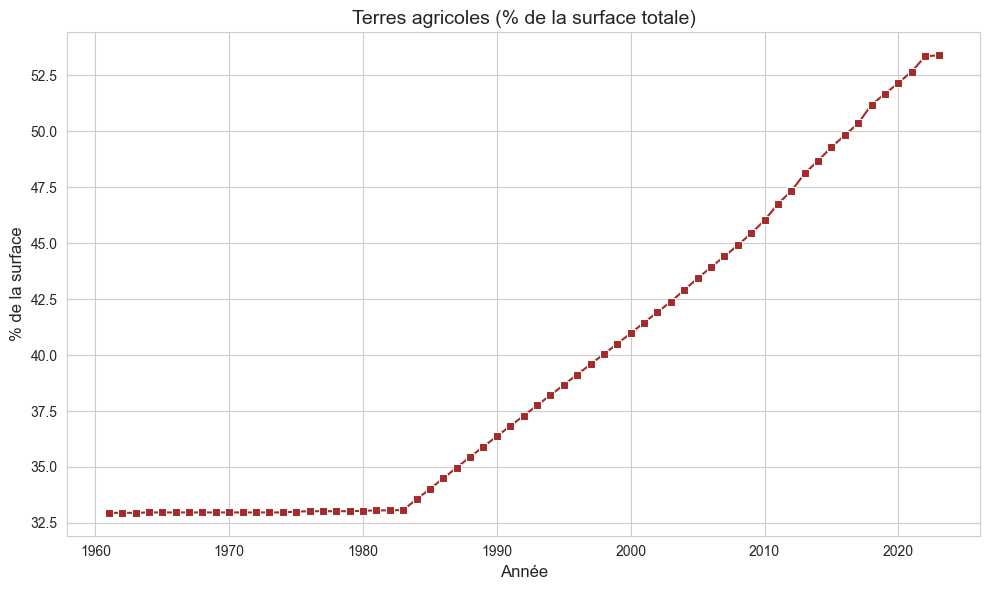

In [15]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=data_land, x='Year', y='Value', marker='s', color='brown')
plt.title('Terres agricoles (% de la surface totale)', fontsize=14)
plt.ylabel('% de la surface', fontsize=12)
plt.xlabel('Année', fontsize=12)
plt.tight_layout()
plt.savefig('plots/terres_agricoles.png', dpi=150)
plt.show()


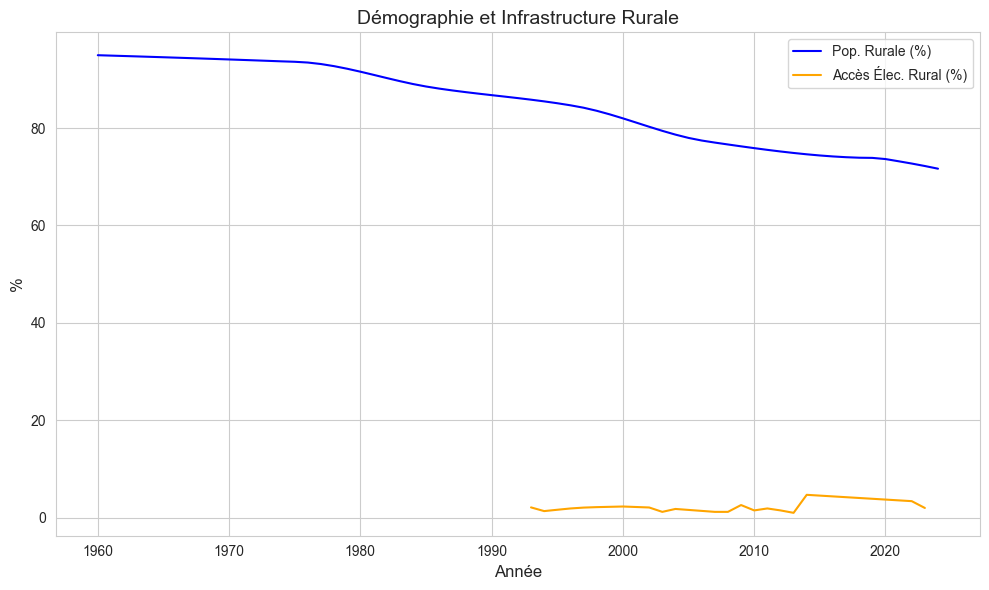

In [16]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=data_pop, x='Year', y='Value', label='Pop. Rurale (%)', color='blue')
sns.lineplot(data=data_elec, x='Year', y='Value', label='Accès Élec. Rural (%)', color='orange')
plt.title('Démographie et Infrastructure Rurale', fontsize=14)
plt.ylabel('%', fontsize=12)
plt.xlabel('Année', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('plots/demographie_infrastructure_rurale.png', dpi=150)
plt.show()


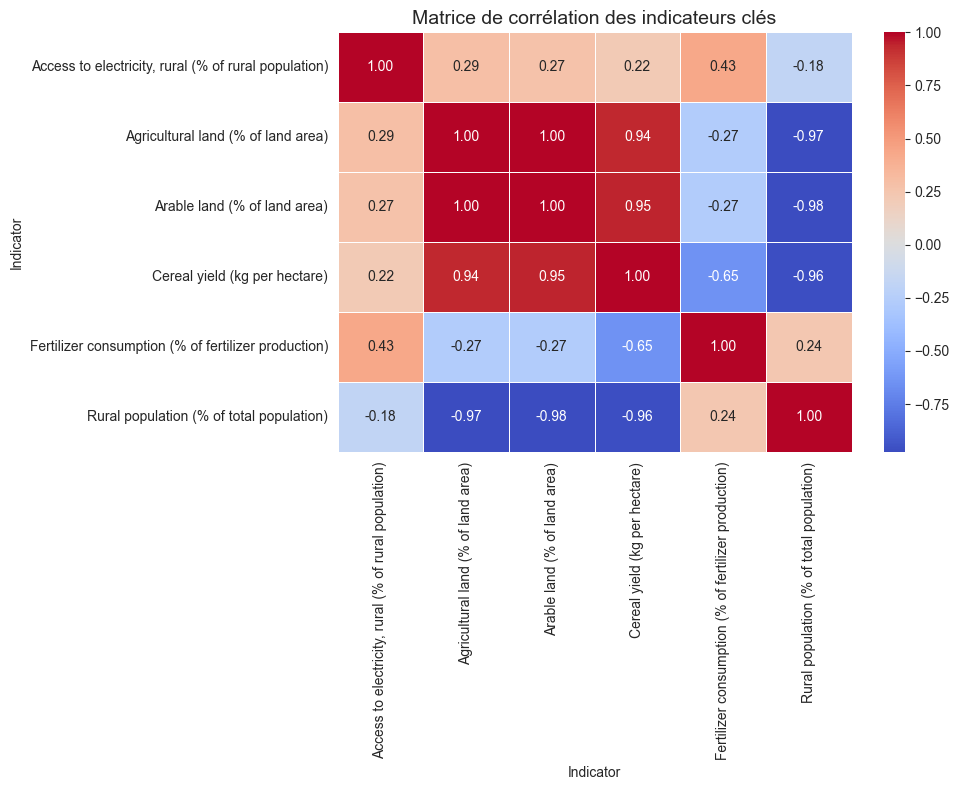

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de corrélation des indicateurs clés', fontsize=14)
plt.tight_layout()
plt.savefig('plots/correlation_indicateurs.png', dpi=150)
plt.show()


## 5. Conclusion

Les analyses montrent que le Burkina Faso fait face à des défis importants en matière de productivité agricole et d'accès aux infrastructures de base en milieu rural. L'investissement dans l'électrification rurale et l'adoption de pratiques agricoles durables sont essentiels pour améliorer la résilience et la sécurité alimentaire du pays.